# Notebook 1: Data Preprocessing & Skill Dictionary Construction
## Multi-Agent Resume Skill Gap Analysis — CSE572 Final Project

This notebook handles:
1. **Dataset loading** — LinkedIn Jobs (1,048 postings) & Resume Dataset (962 resumes)
2. **Text cleaning and normalization**
3. **Curated skill dictionary construction** (100+ skills, 300+ aliases)
4. **Filtering to data-related roles**
5. **Train/validation/test splits (70/15/15)**
6. **Saving preprocessed data for downstream notebooks**

### Datasets
| Dataset | File | Rows | Key Columns |
|---------|------|------|-------------|
| LinkedIn Jobs | `LinkedInDataJobs.csv` | 1,048 | `title`, `description` |
| Resumes | `UpdatedResumeDataSet.csv` | 962 | `Category`, `Resume` |


In [24]:
from google.colab import drive
import os

# 1. Mount the Drive
drive.mount('/content/drive')

# 2. Define the exact path to your project folder
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/DM_project_1'

# 3. List the required folders
required_folders = [
    'data/raw',
    'data/processed',
    'models',
    'outputs'
]

# 4. Create any missing folders directly in Drive
print("Checking Drive folder structure...")
for folder in required_folders:
    path = os.path.join(BASE_DIR, folder)
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"  Created: {path}")
    else:
        print(f"  Verified: {path}")

print("\n✅ Drive is ready. No manual folder creation needed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking Drive folder structure...
  Verified: /content/drive/MyDrive/Colab Notebooks/DM_project_1/data/raw
  Verified: /content/drive/MyDrive/Colab Notebooks/DM_project_1/data/processed
  Verified: /content/drive/MyDrive/Colab Notebooks/DM_project_1/models
  Verified: /content/drive/MyDrive/Colab Notebooks/DM_project_1/outputs

✅ Drive is ready. No manual folder creation needed.


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# ============================================================
# Setup & Dependencies
# ============================================================
!pip install -q spacy scikit-learn sentence-transformers pandas numpy matplotlib seaborn nltk
!python -m spacy download en_core_web_sm -q

import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from collections import Counter
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 200)

print("All dependencies installed and imported successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 31.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed and imported successfully!


In [ ]:
# ============================================================
# Directory Setup
# ============================================================
#os.makedirs('data/raw', exist_ok=True)
#os.makedirs('data/processed', exist_ok=True)
#os.makedirs('outputs', exist_ok=True)
#os.makedirs('models', exist_ok=True)
#print("Directory structure created.")


## 1. Load Datasets

Place your CSV files in `data/raw/`:
- `LinkedInDataJobs.csv`
- `UpdatedResumeDataSet.csv`


In [25]:
# ============================================================
# 1. Load LinkedIn Jobs Dataset
# ============================================================
# Columns: id, title, company, location, link, source, date_posted,
#          work_type, employment_type, description

df_jobs = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DM_project_1/data/raw/LinkedInDataJobs.csv')

print(f"Jobs dataset loaded: {df_jobs.shape[0]} rows, {df_jobs.shape[1]} columns")
print(f"Columns: {list(df_jobs.columns)}")
print(f"\nSample job titles:")
print(df_jobs['title'].value_counts().head(15))
print(f"\nMissing values:")
print(df_jobs[['title', 'description']].isnull().sum())


Jobs dataset loaded: 1048 rows, 10 columns
Columns: ['id', 'title', 'company', 'location', 'link', 'source', 'date_posted', 'work_type', 'employment_type', 'description']

Sample job titles:
title
Data Analyst                         152
Data Scientist                        75
Data Engineer                         58
Data Scientist, Product Analytics     29
Machine Learning Engineer             21
Data Engineer, Product Analytics      20
Senior Data Engineer                  13
Senior Data Analyst                   12
Junior Data Scientist                 11
**** *******                           9
AI/ML Engineer                         9
Junior Data Analyst                    8
Data Analyst II                        7
**** ********, *********               7
Business Data Analyst                  7
Name: count, dtype: int64

Missing values:
title          0
description    4
dtype: int64


In [26]:
# ============================================================
# 2. Load Resume Dataset
# ============================================================
# Columns: Category, Resume

df_resumes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DM_project_1/data/raw/UpdatedResumeDataSet.csv')

print(f"Resume dataset loaded: {df_resumes.shape[0]} rows, {df_resumes.shape[1]} columns")
print(f"Columns: {list(df_resumes.columns)}")
print(f"\nCategory distribution ({df_resumes['Category'].nunique()} categories):")
print(df_resumes['Category'].value_counts())


Resume dataset loaded: 962 rows, 2 columns
Columns: ['Category', 'Resume']

Category distribution (25 categories):
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


## 2. Text Cleaning & Normalization

Apply consistent preprocessing to both datasets:
- Remove HTML tags, URLs, email addresses
- Remove special characters (keep hyphens for multi-word skills)
- Lowercase normalization
- Whitespace normalization
- Lemmatization and stopword removal via spaCy


In [27]:
# ============================================================
# 3. Text Cleaning Pipeline
# ============================================================

nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
nlp.max_length = 2_000_000

def clean_text(text):
    """Basic text cleaning: remove HTML, URLs, special chars, normalize whitespace."""
    if not isinstance(text, str):
        return ''
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    # Remove special characters but keep hyphens, +, #, . (for skills like C++, C#, .NET)
    text = re.sub(r'[^a-zA-Z0-9\s\-\+\#\.]', ' ', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

def spacy_preprocess(text, nlp_model):
    """Lemmatize and remove stopwords using spaCy."""
    if not text:
        return ''
    doc = nlp_model(text[:100000])  # Truncate very long docs
    tokens = [token.lemma_ for token in doc
              if not token.is_stop and not token.is_punct
              and len(token.text) > 1 and token.text.strip()]
    return ' '.join(tokens)

# Clean job descriptions
print("Cleaning job descriptions...")
df_jobs['clean_description'] = df_jobs['description'].apply(clean_text)
print(f"  Done: {len(df_jobs)} job descriptions cleaned")

# Clean resume text
print("Cleaning resume text...")
df_resumes['clean_resume'] = df_resumes['Resume'].apply(clean_text)
print(f"  Done: {len(df_resumes)} resumes cleaned")

# Lemmatize (this takes a few minutes)
print("\nLemmatizing job descriptions (may take a few minutes)...")
df_jobs['processed_description'] = df_jobs['clean_description'].apply(
    lambda x: spacy_preprocess(x, nlp))

print("Lemmatizing resumes...")
df_resumes['processed_resume'] = df_resumes['clean_resume'].apply(
    lambda x: spacy_preprocess(x, nlp))

print("\n✅ Text preprocessing complete!")
print(f"  Jobs: {len(df_jobs)} entries")
print(f"  Resumes: {len(df_resumes)} entries")


Cleaning job descriptions...
  Done: 1048 job descriptions cleaned
Cleaning resume text...
  Done: 962 resumes cleaned

Lemmatizing job descriptions (may take a few minutes)...
Lemmatizing resumes...

✅ Text preprocessing complete!
  Jobs: 1048 entries
  Resumes: 962 entries


In [28]:
# ============================================================
# 4. Handle Missing Values & Duplicates
# ============================================================

print("=== Jobs Dataset ===")
print(f"Missing values in 'description': {df_jobs['description'].isna().sum()}")
print(f"Missing values in 'title': {df_jobs['title'].isna().sum()}")
print(f"Empty cleaned descriptions: {(df_jobs['clean_description'] == '').sum()}")

# Drop rows with empty/very short descriptions
before = len(df_jobs)
df_jobs = df_jobs[df_jobs['clean_description'].str.len() > 20].reset_index(drop=True)
print(f"Dropped {before - len(df_jobs)} jobs with very short/empty descriptions")

# Remove near-duplicate job postings
before = len(df_jobs)
df_jobs = df_jobs.drop_duplicates(subset=['clean_description']).reset_index(drop=True)
print(f"Dropped {before - len(df_jobs)} near-duplicate job postings")

print(f"\n=== Resume Dataset ===")
print(f"Missing values in 'Resume': {df_resumes['Resume'].isna().sum()}")
print(f"Empty cleaned resumes: {(df_resumes['clean_resume'] == '').sum()}")

before = len(df_resumes)
df_resumes = df_resumes[df_resumes['clean_resume'].str.len() > 20].reset_index(drop=True)
print(f"Dropped {before - len(df_resumes)} resumes with very short/empty text")

before = len(df_resumes)
df_resumes = df_resumes.drop_duplicates(subset=['clean_resume']).reset_index(drop=True)
print(f"Dropped {before - len(df_resumes)} near-duplicate resumes")

print(f"\n✅ After cleaning: {len(df_jobs)} jobs, {len(df_resumes)} resumes")


=== Jobs Dataset ===
Missing values in 'description': 4
Missing values in 'title': 0
Empty cleaned descriptions: 4
Dropped 4 jobs with very short/empty descriptions
Dropped 114 near-duplicate job postings

=== Resume Dataset ===
Missing values in 'Resume': 0
Empty cleaned resumes: 0
Dropped 0 resumes with very short/empty text
Dropped 796 near-duplicate resumes

✅ After cleaning: 930 jobs, 166 resumes


## 3. Curated Skill Dictionary

Comprehensive dictionary of data-related skills organized by category. Skills are normalized to canonical forms to ensure consistent matching across resumes and job descriptions.

Sources: O*NET technology skills, common data science job requirements, industry standards.


In [37]:
# ============================================================
# 5. Curated Skill Dictionary
# ============================================================

SKILL_DICTIONARY = {
    # --- Programming Languages ---
    'programming_languages': {
        'python': ['python', 'python3', 'python 3'],
        'r': ['r programming', 'r language', 'rstudio', 'r-studio'],
        'sql': ['sql', 'structured query language', 'tsql', 't-sql', 'plsql', 'pl-sql'],
        'java': ['java', 'java programming'],
        'scala': ['scala'],
        'javascript': ['javascript', 'js', 'node.js', 'nodejs'],
        'c++': ['c++', 'cpp', 'c plus plus'],
        'c#': ['c#', 'csharp', 'c sharp'],
        'sas': ['sas', 'sas programming'],
        'matlab': ['matlab'],
        'julia': ['julia'],
        'bash': ['bash', 'shell scripting', 'shell script'],
        'php': ['php'],
        'ruby': ['ruby'],
        'go': ['golang'],
        'typescript': ['typescript'],
        'html': ['html', 'html5'],
        'css': ['css', 'css3'],
    },

    # --- Machine Learning & AI ---
    'machine_learning': {
        'machine learning': ['machine learning', 'ml', 'ml algorithms'],
        'deep learning': ['deep learning', 'dl', 'neural network', 'neural networks', 'deep neural'],
        'natural language processing': ['natural language processing', 'nlp', 'text mining', 'text analytics'],
        'computer vision': ['computer vision', 'image recognition', 'image processing', 'object detection'],
        'reinforcement learning': ['reinforcement learning'],
        'supervised learning': ['supervised learning', 'classification', 'regression'],
        'unsupervised learning': ['unsupervised learning', 'clustering', 'dimensionality reduction'],
        'feature engineering': ['feature engineering', 'feature extraction', 'feature selection'],
        'model deployment': ['model deployment', 'model serving', 'mlops', 'ml ops'],
        'transfer learning': ['transfer learning', 'pre-trained model', 'fine-tuning', 'fine tuning'],
        'time series': ['time series', 'time-series', 'forecasting', 'time series analysis'],
        'recommendation systems': ['recommendation system', 'recommender system', 'collaborative filtering'],
        'anomaly detection': ['anomaly detection', 'outlier detection'],
        'ensemble methods': ['ensemble', 'random forest', 'gradient boosting', 'xgboost', 'lightgbm', 'catboost', 'bagging', 'boosting'],
    },

    # --- ML/DL Frameworks ---
    'ml_frameworks': {
        'tensorflow': ['tensorflow', 'tf', 'tensorflow 2'],
        'pytorch': ['pytorch', 'torch'],
        'scikit-learn': ['scikit-learn', 'sklearn', 'scikit learn'],
        'keras': ['keras'],
        'hugging face': ['hugging face', 'huggingface', 'transformers library'],
        'opencv': ['opencv', 'cv2'],
        'spacy': ['spacy'],
        'nltk': ['nltk'],
        'xgboost': ['xgboost', 'xgb'],
        'lightgbm': ['lightgbm', 'lgbm'],
    },

    # --- Data Engineering & Databases ---
    'data_engineering': {
        'etl': ['etl', 'elt', 'data pipeline', 'data pipelines', 'data integration'],
        'apache spark': ['spark', 'apache spark', 'pyspark'],
        'hadoop': ['hadoop', 'hdfs', 'mapreduce', 'map reduce', 'hive'],
        'apache kafka': ['kafka', 'apache kafka'],
        'apache airflow': ['airflow', 'apache airflow'],
        'data warehousing': ['data warehouse', 'data warehousing', 'dwh', 'data mart'],
        'snowflake': ['snowflake'],
        'databricks': ['databricks'],
        'dbt': ['dbt', 'data build tool'],
        'data lake': ['data lake', 'data lakehouse'],
        'mongodb': ['mongodb', 'mongo'],
        'redis': ['redis'],
        'elasticsearch': ['elasticsearch', 'elastic search', 'elk stack'],
        'postgresql': ['postgresql', 'postgres'],
        'mysql': ['mysql'],
        'oracle': ['oracle', 'oracle db'],
        'nosql': ['nosql', 'no-sql', 'non-relational'],
        'sql server': ['sql server', 'mssql', 'microsoft sql server'],
        'cassandra': ['cassandra'],
    },

    # --- Data Analysis & Visualization ---
    'data_analysis': {
        'data analysis': ['data analysis', 'data analytics', 'data-driven', 'analytical skills'],
        'statistical analysis': ['statistical analysis', 'statistics', 'statistical modeling', 'statistical methods', 'hypothesis testing'],
        'a/b testing': ['a/b testing', 'ab testing', 'a-b testing', 'experimentation'],
        'pandas': ['pandas'],
        'numpy': ['numpy'],
        'scipy': ['scipy'],
        'data visualization': ['data visualization', 'data viz', 'visualization'],
        'tableau': ['tableau'],
        'power bi': ['power bi', 'powerbi', 'power-bi'],
        'matplotlib': ['matplotlib'],
        'seaborn': ['seaborn'],
        'plotly': ['plotly'],
        'd3.js': ['d3', 'd3.js', 'd3js'],
        'looker': ['looker'],
        'excel': ['excel', 'microsoft excel', 'ms excel', 'spreadsheet', 'vlookup', 'pivot table'],
        'google analytics': ['google analytics'],
    },

    # --- Cloud & DevOps ---
    'cloud_devops': {
        'aws': ['aws', 'amazon web services', 'ec2', 's3', 'sagemaker', 'lambda', 'redshift'],
        'gcp': ['gcp', 'google cloud', 'google cloud platform', 'bigquery', 'big query'],
        'azure': ['azure', 'microsoft azure', 'azure ml'],
        'docker': ['docker', 'containerization', 'containers'],
        'kubernetes': ['kubernetes', 'k8s'],
        'git': ['git', 'github', 'gitlab', 'version control', 'bitbucket'],
        'ci/cd': ['ci/cd', 'cicd', 'ci-cd', 'continuous integration', 'continuous deployment', 'jenkins'],
        'terraform': ['terraform', 'infrastructure as code', 'iac'],
        'linux': ['linux', 'unix', 'ubuntu', 'centos'],
        'ansible': ['ansible'],
        'puppet': ['puppet'],
        'chef': ['chef'],
    },

    # --- Web & Software Development ---
    'web_development': {
        'react': ['react', 'reactjs', 'react.js'],
        'angular': ['angular', 'angularjs'],
        'vue': ['vue', 'vuejs', 'vue.js'],
        'django': ['django'],
        'flask': ['flask'],
        'spring boot': ['spring boot', 'spring framework', 'spring'],
        'rest api': ['rest api', 'restful', 'api development', 'api'],
        'graphql': ['graphql'],
        'microservices': ['microservices', 'microservice'],
        '.net': ['.net', 'dotnet', 'dot net', 'asp.net'],
        'hibernate': ['hibernate'],
    },

    # --- Testing & QA ---
    'testing': {
        'selenium': ['selenium'],
        'pytest': ['pytest'],
        'junit': ['junit'],
        'test automation': ['test automation', 'automated testing', 'automation testing'],
        'manual testing': ['manual testing'],
        'performance testing': ['performance testing', 'load testing', 'jmeter'],
        'api testing': ['api testing', 'postman'],
    },

    # --- Blockchain & Specialized ---
    'specialized': {
        'blockchain': ['blockchain', 'smart contract', 'ethereum', 'solidity', 'web3'],
        'generative ai': ['generative ai', 'genai', 'gen ai', 'llm', 'large language model', 'chatgpt', 'gpt'],
        'data governance': ['data governance', 'data quality', 'data stewardship'],
        'data modeling': ['data modeling', 'data modelling', 'dimensional modeling', 'star schema'],
        'web scraping': ['web scraping', 'web crawling', 'beautifulsoup', 'scrapy'],
        'sap': ['sap', 'sap hana', 'sap abap'],
        'network security': ['network security', 'cybersecurity', 'cyber security', 'penetration testing',
                            'firewall', 'intrusion detection', 'ids', 'ips', 'siem'],
    },

    # --- Soft Skills & Domain ---
    'soft_skills': {
        'communication': ['communication', 'presentation', 'storytelling', 'stakeholder management'],
        'problem solving': ['problem solving', 'problem-solving', 'critical thinking', 'analytical thinking'],
        'teamwork': ['teamwork', 'collaboration', 'cross-functional', 'cross functional'],
        'project management': ['project management', 'agile', 'scrum', 'kanban', 'jira'],
        'leadership': ['leadership', 'team lead', 'mentoring'],
        'business acumen': ['business acumen', 'business intelligence', 'domain knowledge', 'business strategy'],
        'research': ['research', 'literature review', 'academic research'],
    },
}

# Flatten for quick lookup
def build_skill_lookup(skill_dict):
    """Build a flat lookup: alias -> canonical_skill_name, and canonical -> category."""
    lookup = {}
    category_map = {}
    for category, skills in skill_dict.items():
        for canonical, aliases in skills.items():
            category_map[canonical] = category
            for alias in aliases:
                lookup[alias.lower()] = canonical
    return lookup, category_map

skill_lookup, skill_category_map = build_skill_lookup(SKILL_DICTIONARY)

print(f"Skill dictionary built:")
print(f"  Categories: {len(SKILL_DICTIONARY)}")
print(f"  Canonical skills: {len(skill_category_map)}")
print(f"  Total aliases (including multi-word): {len(skill_lookup)}")
print(f"\nCategories: {list(SKILL_DICTIONARY.keys())}")
print(f"\nSkills per category:")
for cat, skills in SKILL_DICTIONARY.items():
    print(f"  {cat}: {len(skills)} skills")

# Save
# Define the processed folder path
processed_path = os.path.join(BASE_DIR, 'data/processed')

# Save all JSON files directly to Drive
with open(os.path.join(processed_path, 'skill_dictionary.json'), 'w') as f:
    json.dump(SKILL_DICTIONARY, f, indent=2)

with open(os.path.join(processed_path, 'skill_lookup.json'), 'w') as f:
    json.dump(skill_lookup, f, indent=2)

with open(os.path.join(processed_path, 'skill_category_map.json'), 'w') as f:
    json.dump(skill_category_map, f, indent=2)

print(f"✅ All dictionary files successfully saved to Drive at: {processed_path}")

# with open('data/processed/skill_dictionary.json', 'w') as f:
#     json.dump(SKILL_DICTIONARY, f, indent=2)
# with open('data/processed/skill_lookup.json', 'w') as f:
#     json.dump(skill_lookup, f, indent=2)
# with open('data/processed/skill_category_map.json', 'w') as f:
#     json.dump(skill_category_map, f, indent=2)

# print("\n✅ Skill dictionary saved to data/processed/")


Skill dictionary built:
  Categories: 10
  Canonical skills: 121
  Total aliases (including multi-word): 332

Categories: ['programming_languages', 'machine_learning', 'ml_frameworks', 'data_engineering', 'data_analysis', 'cloud_devops', 'web_development', 'testing', 'specialized', 'soft_skills']

Skills per category:
  programming_languages: 18 skills
  machine_learning: 14 skills
  ml_frameworks: 10 skills
  data_engineering: 19 skills
  data_analysis: 16 skills
  cloud_devops: 12 skills
  web_development: 11 skills
  testing: 7 skills
  specialized: 7 skills
  soft_skills: 7 skills
✅ All dictionary files successfully saved to Drive at: /content/drive/MyDrive/Colab Notebooks/DM_project_1/data/processed


## 4. Filter to Data-Related Roles

We filter both datasets to data/tech-related roles to align with project scope.

**Jobs**: Filter by title keywords (data, analyst, engineer, ML, etc.)
**Resumes**: Filter by Category column — keep tech-relevant categories from the 25 available.


In [30]:
# ============================================================
# 6. Filter to Data-Related Roles
# ============================================================

# --- Filter Jobs by Title ---
DATA_ROLE_KEYWORDS = [
    'data', 'analyst', 'analytics', 'scientist', 'machine learning',
    'ml', 'ai', 'engineer', 'deep learning', 'intelligence',
    'statistician', 'quantitative', 'nlp', 'database',
    'python', 'big data', 'mlops', 'research',
]

def is_data_role(title):
    if not isinstance(title, str):
        return False
    title_lower = title.lower()
    return any(kw in title_lower for kw in DATA_ROLE_KEYWORDS)

df_jobs['is_data_role'] = df_jobs['title'].apply(is_data_role)
df_jobs_filtered = df_jobs[df_jobs['is_data_role']].copy().reset_index(drop=True)

print(f"Jobs filtered to data/tech roles: {len(df_jobs_filtered)} / {len(df_jobs)} "
      f"({100*len(df_jobs_filtered)/len(df_jobs):.1f}%)")
print(f"\nTop job titles in filtered set:")
print(df_jobs_filtered['title'].value_counts().head(15))

# --- Filter Resumes by Category ---
# These are the tech/data-related categories from the 25 categories in the dataset
DATA_RESUME_CATEGORIES = [
    'Data Science', 'Database', 'Python Developer', 'Java Developer',
    'Web Designing', 'Hadoop', 'ETL Developer', 'Blockchain',
    'DevOps Engineer', 'Automation Testing', 'Testing',
    'DotNet Developer', 'Network Security Engineer',
    'Business Analyst', 'SAP Developer',
]

df_resumes['is_data_role'] = df_resumes['Category'].isin(DATA_RESUME_CATEGORIES)
df_resumes_filtered = df_resumes[df_resumes['is_data_role']].copy().reset_index(drop=True)

print(f"\nResumes filtered to tech roles: {len(df_resumes_filtered)} / {len(df_resumes)} "
      f"({100*len(df_resumes_filtered)/len(df_resumes):.1f}%)")
print(f"\nCategory distribution in filtered set:")
print(df_resumes_filtered['Category'].value_counts())


Jobs filtered to data/tech roles: 813 / 930 (87.4%)

Top job titles in filtered set:
title
Data Analyst                         139
Data Scientist                        70
Data Engineer                         49
Machine Learning Engineer             21
Senior Data Engineer                  13
Senior Data Analyst                   11
Junior Data Scientist                 11
Data Scientist, Product Analytics      9
Junior Data Analyst                    8
Business Data Analyst                  7
Data Analyst II                        5
Data Engineer I                        5
AI/ML Engineer                         5
Data Analyst I                         5
Data Engineer I, SCOT - AIM            4
Name: count, dtype: int64

Resumes filtered to tech roles: 106 / 166 (63.9%)

Category distribution in filtered set:
Category
Java Developer               13
Database                     11
Data Science                 10
DotNet Developer              7
Hadoop                        7
DevOps E

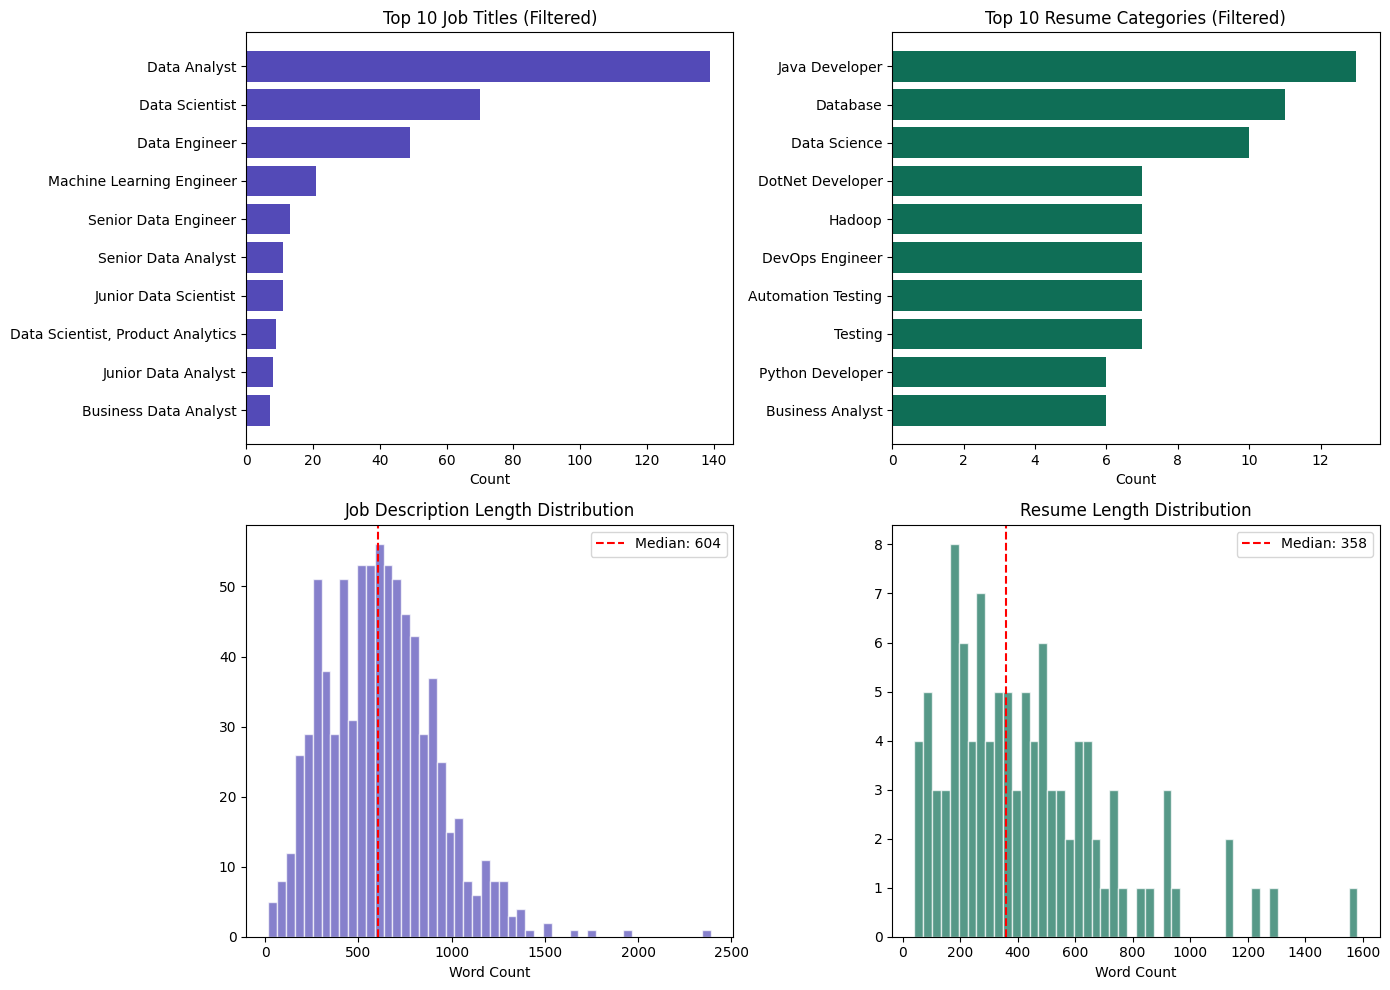

✅ Exploration plots saved to outputs/01_data_exploration.png


In [31]:
# ============================================================
# 7. Exploratory Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 7a. Job title distribution (top 10)
top_titles = df_jobs_filtered['title'].value_counts().head(10)
axes[0, 0].barh(top_titles.index, top_titles.values, color='#534AB7')
axes[0, 0].set_title('Top 10 Job Titles (Filtered)')
axes[0, 0].set_xlabel('Count')
axes[0, 0].invert_yaxis()

# 7b. Resume category distribution
cat_counts = df_resumes_filtered['Category'].value_counts().head(10)
axes[0, 1].barh(cat_counts.index, cat_counts.values, color='#0F6E56')
axes[0, 1].set_title('Top 10 Resume Categories (Filtered)')
axes[0, 1].set_xlabel('Count')
axes[0, 1].invert_yaxis()

# 7c. Job description length distribution
desc_lengths = df_jobs_filtered['clean_description'].str.split().str.len()
axes[1, 0].hist(desc_lengths, bins=50, color='#534AB7', alpha=0.7, edgecolor='white')
axes[1, 0].set_title('Job Description Length Distribution')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].axvline(desc_lengths.median(), color='red', linestyle='--',
                   label=f'Median: {desc_lengths.median():.0f}')
axes[1, 0].legend()

# 7d. Resume length distribution
resume_lengths = df_resumes_filtered['clean_resume'].str.split().str.len()
axes[1, 1].hist(resume_lengths, bins=50, color='#0F6E56', alpha=0.7, edgecolor='white')
axes[1, 1].set_title('Resume Length Distribution')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].axvline(resume_lengths.median(), color='red', linestyle='--',
                   label=f'Median: {resume_lengths.median():.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('outputs/01_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Exploration plots saved to outputs/01_data_exploration.png")


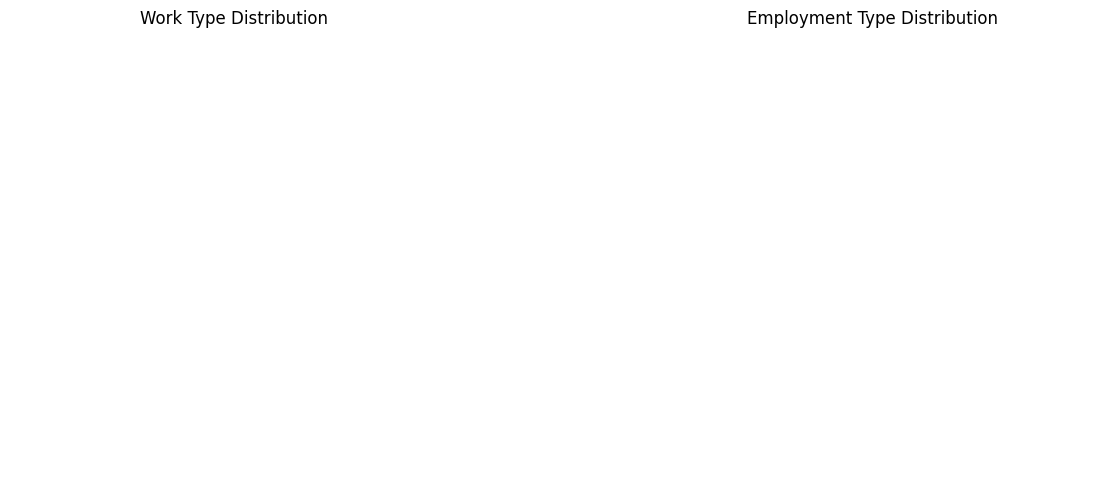

In [32]:
# ============================================================
# 7b. Additional Job Metadata Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Work type distribution
if 'work_type' in df_jobs_filtered.columns:
    work_types = df_jobs_filtered['work_type'].value_counts()
    axes[0].pie(work_types.values, labels=work_types.index, autopct='%1.1f%%',
                startangle=90, colors=sns.color_palette('Set2'))
    axes[0].set_title('Work Type Distribution')

# Employment type distribution
if 'employment_type' in df_jobs_filtered.columns:
    emp_types = df_jobs_filtered['employment_type'].value_counts()
    axes[1].pie(emp_types.values, labels=emp_types.index, autopct='%1.1f%%',
                startangle=90, colors=sns.color_palette('Set3'))
    axes[1].set_title('Employment Type Distribution')

plt.tight_layout()
plt.savefig('outputs/01_job_metadata.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Train / Validation / Test Splits (70/15/15)


In [34]:
# ============================================================
# 8. Dataset Splits (70/15/15)
# ============================================================

# Jobs: 70/15/15 split
jobs_train, jobs_temp = train_test_split(
    df_jobs_filtered, test_size=0.30, random_state=42)
jobs_val, jobs_test = train_test_split(
    jobs_temp, test_size=0.50, random_state=42)

print("Jobs splits:")
print(f"  Train: {len(jobs_train)} ({100*len(jobs_train)/len(df_jobs_filtered):.1f}%)")
print(f"  Val:   {len(jobs_val)} ({100*len(jobs_val)/len(df_jobs_filtered):.1f}%)")
print(f"  Test:  {len(jobs_test)} ({100*len(jobs_test)/len(df_jobs_filtered):.1f}%)")

# Resumes: 70/15/15 stratified split by Category
try:
    resumes_train, resumes_temp = train_test_split(
        df_resumes_filtered, test_size=0.30, random_state=42,
        stratify=df_resumes_filtered['Category'])
    resumes_val, resumes_test = train_test_split(
        resumes_temp, test_size=0.50, random_state=42,
        stratify=resumes_temp['Category'])
    print("\nResume splits (stratified by Category):")
except ValueError:
    # Fallback if some categories too small for stratification
    print("\nNote: Some categories too small for stratified split, using random split")
    resumes_train, resumes_temp = train_test_split(
        df_resumes_filtered, test_size=0.30, random_state=42)
    resumes_val, resumes_test = train_test_split(
        resumes_temp, test_size=0.50, random_state=42)
    print("Resume splits (random):")

print(f"  Train: {len(resumes_train)} ({100*len(resumes_train)/len(df_resumes_filtered):.1f}%)")
print(f"  Val:   {len(resumes_val)} ({100*len(resumes_val)/len(df_resumes_filtered):.1f}%)")
print(f"  Test:  {len(resumes_test)} ({100*len(resumes_test)/len(df_resumes_filtered):.1f}%)")

# Verify stratification
print(f"\nCategory distribution in train set:")
print(resumes_train['Category'].value_counts())


Jobs splits:
  Train: 569 (70.0%)
  Val:   122 (15.0%)
  Test:  122 (15.0%)

Note: Some categories too small for stratified split, using random split
Resume splits (random):
  Train: 74 (69.8%)
  Val:   16 (15.1%)
  Test:  16 (15.1%)

Category distribution in train set:
Category
Java Developer               9
Data Science                 8
Database                     7
DevOps Engineer              6
Testing                      6
DotNet Developer             5
ETL Developer                5
Python Developer             5
Automation Testing           4
Business Analyst             4
Blockchain                   4
Network Security Engineer    4
SAP Developer                4
Hadoop                       2
Web Designing                1
Name: count, dtype: int64


In [35]:
# ============================================================
# 9. Save Preprocessed Data
# ============================================================

# Save full filtered datasets
df_jobs_filtered.to_csv('data/processed/jobs_filtered.csv', index=False)
df_resumes_filtered.to_csv('data/processed/resumes_filtered.csv', index=False)

# Save splits
jobs_train.to_csv('data/processed/jobs_train.csv', index=False)
jobs_val.to_csv('data/processed/jobs_val.csv', index=False)
jobs_test.to_csv('data/processed/jobs_test.csv', index=False)

resumes_train.to_csv('data/processed/resumes_train.csv', index=False)
resumes_val.to_csv('data/processed/resumes_val.csv', index=False)
resumes_test.to_csv('data/processed/resumes_test.csv', index=False)

# Save column name mapping for downstream notebooks
# These are the ACTUAL column names from your datasets
col_config = {
    'jobs_title_col': 'title',
    'jobs_desc_col': 'description',
    'resume_text_col': 'Resume',
    'resume_cat_col': 'Category',
}
with open('data/processed/column_config.json', 'w') as f:
    json.dump(col_config, f, indent=2)

print("✅ All preprocessed data saved to data/processed/")
print("\nFiles saved:")
for f_name in sorted(os.listdir('data/processed')):
    size = os.path.getsize(f'data/processed/{f_name}')
    print(f"  {f_name}: {size/1024:.1f} KB")


✅ All preprocessed data saved to data/processed/

Files saved:
  column_config.json: 0.1 KB
  jobs_filtered.csv: 9325.1 KB
  jobs_test.csv: 1272.5 KB
  jobs_train.csv: 6689.6 KB
  jobs_val.csv: 1363.2 KB
  resumes_filtered.csv: 887.2 KB
  resumes_test.csv: 141.4 KB
  resumes_train.csv: 599.5 KB
  resumes_val.csv: 146.4 KB
  skill_category_map.json: 4.0 KB
  skill_dictionary.json: 9.7 KB
  skill_lookup.json: 9.7 KB


In [36]:
# ============================================================
# 10. Preprocessing Summary
# ============================================================

print("=" * 60)
print("PHASE 1 SUMMARY")
print("=" * 60)
print(f"\nDatasets:")
print(f"  LinkedIn Jobs:  {len(df_jobs)} raw → {len(df_jobs_filtered)} filtered")
print(f"  Resumes:        {len(df_resumes)} raw → {len(df_resumes_filtered)} filtered")
print(f"\nSkill Dictionary:")
print(f"  Categories: {len(SKILL_DICTIONARY)}")
print(f"  Canonical skills: {len(skill_category_map)}")
print(f"  Total aliases: {len(skill_lookup)}")
print(f"\nSplits (filtered data):")
print(f"  Jobs  — Train: {len(jobs_train)}, Val: {len(jobs_val)}, Test: {len(jobs_test)}")
print(f"  Resumes — Train: {len(resumes_train)}, Val: {len(resumes_val)}, Test: {len(resumes_test)}")
print(f"\nColumn mapping saved:")
for k, v in col_config.items():
    print(f"  {k}: '{v}'")
print(f"\n{'='*60}")
print("PHASE 1 COMPLETE — Run Notebook 02 next: Skill Extraction")
print(f"{'='*60}")


PHASE 1 SUMMARY

Datasets:
  LinkedIn Jobs:  930 raw → 813 filtered
  Resumes:        166 raw → 106 filtered

Skill Dictionary:
  Categories: 10
  Canonical skills: 121
  Total aliases: 332

Splits (filtered data):
  Jobs  — Train: 569, Val: 122, Test: 122
  Resumes — Train: 74, Val: 16, Test: 16

Column mapping saved:
  jobs_title_col: 'title'
  jobs_desc_col: 'description'
  resume_text_col: 'Resume'
  resume_cat_col: 'Category'

PHASE 1 COMPLETE — Run Notebook 02 next: Skill Extraction


In [ ]:
# import shutil
# import os

# # 1. This is the destination on your Google Drive
# drive_project_path = '/content/drive/MyDrive/Colab Notebooks/DM_project_1'

# # 2. These are the temporary folders located in the Colab 'content' area
# folders_to_move = ['data', 'models', 'outputs']

# for folder in folders_to_move:
#     # This points to the temporary local Colab directory
#     local_folder_path = f'/content/{folder}'
#     # This points to the permanent destination in your Drive
#     drive_folder_path = os.path.join(drive_project_path, folder)

#     if os.path.exists(local_folder_path):
#         # Clean up existing folder in Drive to avoid 'FileExists' errors during copy
#         if os.path.exists(drive_folder_path):
#             shutil.rmtree(drive_folder_path)

#         # Move the folder from Colab local to Google Drive
#         shutil.copytree(local_folder_path, drive_folder_path)
#         print(f"✅ Successfully backed up '{folder}' to Drive.")
#     else:
#         print(f"⚠️ Folder '{folder}' not found in local Colab environment. Did you run the creation code?")

# print(f"\nAll Phase 1 assets are now synced to: {drive_project_path}")